In [1]:
import pandas as pd
df = pd.read_csv("ratings.csv")
df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [2]:
!pip3 install pandas matplotlib

In [3]:
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
df = df.sort_values(by=["movieId","timestamp"])

In [4]:
df["order"] = df.groupby("movieId").cumcount()+1
early = df[df["order"]<=20]
later =df[df["order"]>20]

In [5]:
early_avg = early.groupby("movieId")["rating"].mean()
later_avg = later.groupby("movieId")["rating"].mean()
combined = pd.DataFrame({
    "EarlyAvg":early_avg,
    "LaterAvg":later_avg
}).dropna()

combined.head()

,EarlyAvg,LaterAvg
movieId,,
1,4.10,3.902564
2,3.95,3.316667
3,3.60,3.046875
5,3.30,2.913793
6,3.60,4.030488


combined.corr()

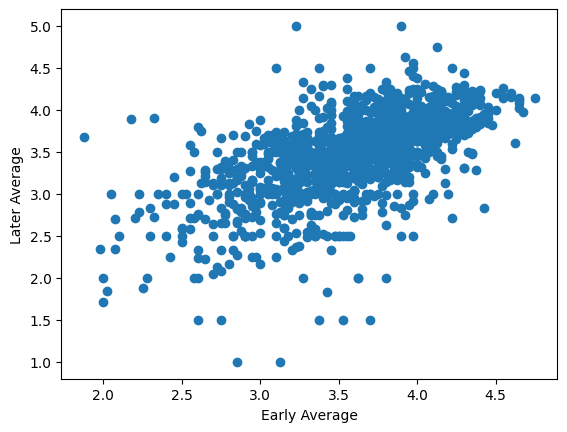

In [6]:
import matplotlib.pyplot as plt
plt.scatter(combined["EarlyAvg"], combined ["LaterAvg"])
plt.xlabel("Early Average")
plt.ylabel("Later Average")
plt.show()

In [7]:
high = combined[combined["EarlyAvg"] > 4]
low = combined[combined["EarlyAvg"] <3]
print(high["LaterAvg"].mean())
print(low["LaterAvg"].mean())
      

3.8761680180735922
2.8650635987976276


In [8]:
import statsmodels.api as sm
X = combined ["EarlyAvg"]
X = sm.add_constant(X)
y = combined["LaterAvg"]
model = sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               LaterAvg   R-squared:                       0.385
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     772.4
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          2.19e-132
Time:                        10:46:14   Log-Likelihood:                -636.28
No. Observations:                1235   AIC:                             1277.
Df Residuals:                    1233   BIC:                             1287.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1310      0.085     13.317      0.0

!pip3 install statsmodels



In [10]:
early = df[df["order"] <= 10]
later = df[df["order"] > 10]

In [11]:
early_avg = early.groupby("movieId")["rating"].mean()
later_avg = later.groupby("movieId")["rating"].mean()
combined = pd.DataFrame({
    "EarlyAvg":early_avg,
    "LaterAvg":later_avg
}).dropna()

combined.head()

,EarlyAvg,LaterAvg
movieId,,
1,3.9,3.921951
2,4.3,3.345000
3,3.9,3.107143
5,3.3,3.012821
6,3.7,3.972826


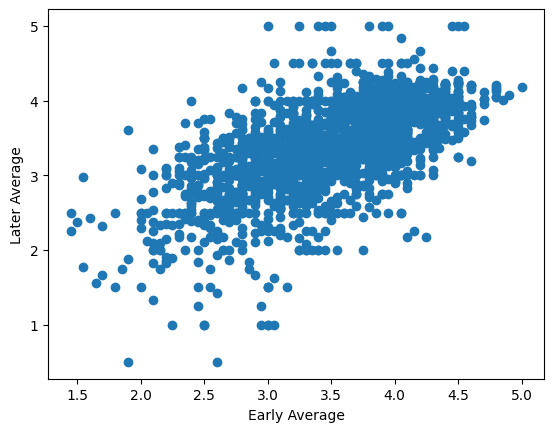

In [12]:
import matplotlib.pyplot as plt
plt.scatter(combined["EarlyAvg"], combined ["LaterAvg"])
plt.xlabel("Early Average")
plt.ylabel("Later Average")
plt.show()

In [13]:
high = combined[combined["EarlyAvg"] > 4]
low = combined[combined["EarlyAvg"] <3]
print(high["LaterAvg"].mean())
print(low["LaterAvg"].mean())
      

3.8353645624885733
2.791758087975995


In [15]:
import statsmodels.api as sm
X = combined ["EarlyAvg"]
X = sm.add_constant(X)
y = combined["LaterAvg"]
model = sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               LaterAvg   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     1430.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          1.48e-239
Time:                        10:49:32   Log-Likelihood:                -1333.7
No. Observations:                2121   AIC:                             2671.
Df Residuals:                    2119   BIC:                             2683.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1344      0.061     18.727      0.0